In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from pathlib import Path
df = pd.read_csv("fixed.csv")

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6511 entries, 0 to 6510
Data columns (total 27 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0.1     6511 non-null   int64  
 1   imagename        6496 non-null   object 
 2   Unnamed: 0       6511 non-null   int64  
 3   image_index      6511 non-null   float64
 4   crop_index       6511 non-null   float64
 5   image_name       6511 non-null   object 
 6   area             6511 non-null   float64
 7   x                6511 non-null   float64
 8   y                6511 non-null   float64
 9   w                6511 non-null   float64
 10  h                6511 non-null   float64
 11  aspect_ratio     6511 non-null   float64
 12  std              6511 non-null   float64
 13  bright_fraction  6511 non-null   float64
 14  dark_fraction    6511 non-null   float64
 15  min_val          6511 non-null   float64
 16  max_val          6511 non-null   float64
 17  reason        

In [67]:
df['is_rejected'].unique()

array(['no', 'yes'], dtype=object)

In [68]:
df["is_rejected"] = df["is_rejected"].astype(str).str.lower().map({
    "yes": True,
    "no": False
})


In [69]:
df = df.dropna(subset=["image_filename"]).reset_index(drop=True)

In [70]:
df['cluster_id'].unique()

array([ 3, 19,  1,  9,  6,  5, 18,  0, 10,  8, 12, 15, 11,  7, 13,  2, 14,
       16, 17,  4])

In [ ]:
name_source = df["image_filename"].where(df["image_filename"].notna(), df["filename"])

def parse_cluster_anchor_similarity(name):
    """
    Extract:
      cluster_id   → parts[3]
      is_anchor    → (parts[4] == 1)
      similarity_to_anchor → float(parts[0]) ONLY if is_anchor == False
    """
    if pd.isna(name):
        return pd.Series([np.nan, False, np.nan])

    s = str(name)
    stem = Path(s).stem
    first_token = stem.split()[0]
    parts = first_token.split("_")

    if len(parts) >= 5:
        try:
            cluster_id = int(parts[3])
            is_anchor = int(parts[4]) == 1

            # Only non anchors get similarity value
            if not is_anchor:
                similarity_to_anchor = float(parts[0])
            else:
                similarity_to_anchor = np.nan

            return pd.Series([cluster_id, is_anchor, similarity_to_anchor])
        except ValueError:
            return pd.Series([np.nan, False, np.nan])

    return pd.Series([np.nan, False, np.nan])


# Apply to dataframe
df[["cluster_id", "is_anchor", "similarity_to_anchor"]] = name_source.apply(
    parse_cluster_anchor_similarity
)

# Clean dtypes
df["cluster_id"] = df["cluster_id"].astype("Int64")
df["similarity_to_anchor"] = pd.to_numeric(df["similarity_to_anchor"], errors="coerce")


In [72]:
# Ensure cluster_id is numeric
df["cluster_id"] = pd.to_numeric(df["cluster_id"], errors="coerce")

# Unique taxonomy counts
n_orders    = df["order"].dropna().nunique()
n_suborders = df["suborder"].dropna().nunique()
n_families  = df["family"].dropna().nunique()

print(f"Number of orders   : {n_orders}")
print(f"Number of suborders: {n_suborders}")
print(f"Number of families : {n_families}")

# Cluster counts vs 20
clusters_used = df["cluster_id"].dropna().nunique()
print(f"\nClusters used in data        : {clusters_used}")
print(f"Planned number of clusters   : 20")
print(f"Difference (used - planned)  : {clusters_used - 20}")

Number of orders   : 15
Number of suborders: 5
Number of families : 23

Clusters used in data        : 20
Planned number of clusters   : 20
Difference (used - planned)  : 0


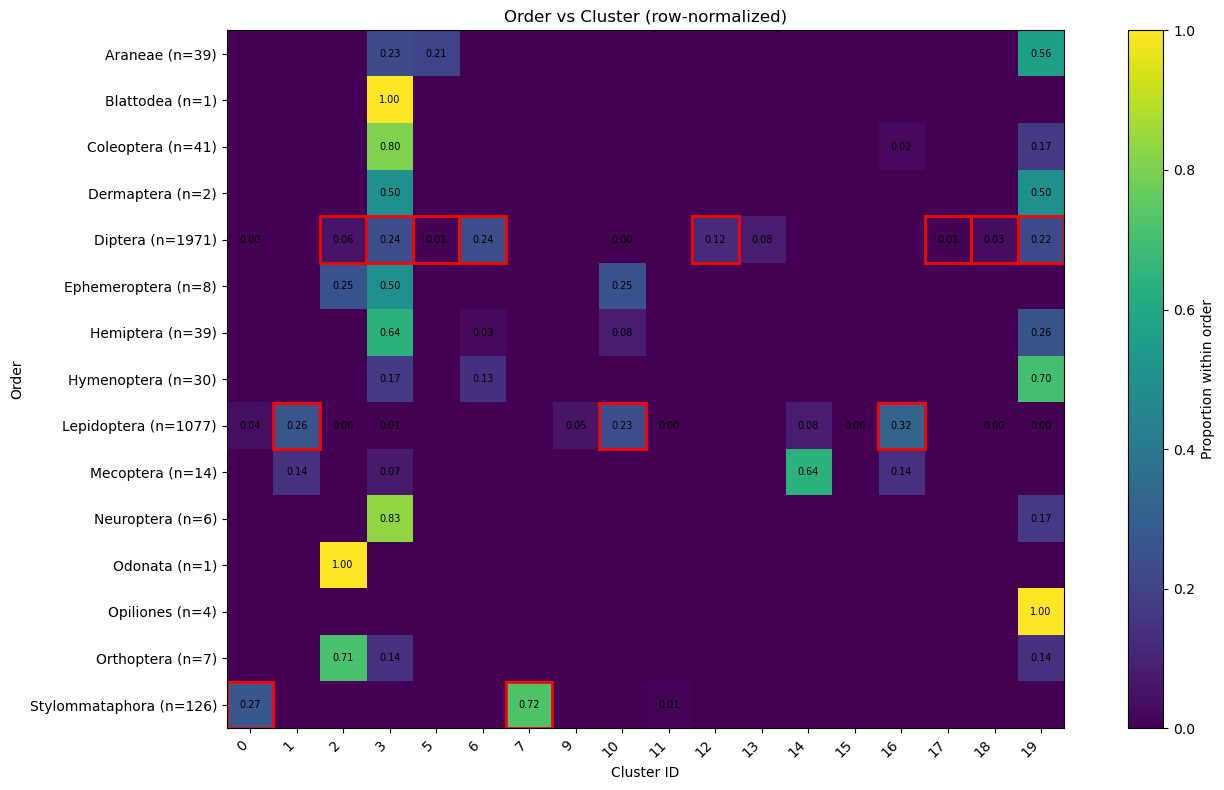

In [73]:
#   Prepare data: drop rows without order or cluster  
df_oc = df.dropna(subset=["order", "cluster_id"]).copy()
df_oc["cluster_id"] = df_oc["cluster_id"].astype(int)

#   Raw confusion counts: order x cluster  
conf_counts_oc = pd.crosstab(df_oc["order"], df_oc["cluster_id"])
order_counts = conf_counts_oc.sum(axis=1)
#   Row-normalize (per order)  
conf_norm_oc = conf_counts_oc.div(conf_counts_oc.sum(axis=1), axis=0).fillna(0)

#   Anchor mask: True if any anchor from that cluster appears in that order  
anchors_oc = df_oc[df_oc["is_anchor"] == True]
anchor_mask_oc = (
    anchors_oc
    .groupby(["order", "cluster_id"])
    .size()
    .unstack(fill_value=0)
) > 0

# Align shapes
conf_norm_oc = conf_norm_oc.sort_index().sort_index(axis=1)
anchor_mask_oc = anchor_mask_oc.reindex(
    index=conf_norm_oc.index,
    columns=conf_norm_oc.columns,
    fill_value=False
)

cm_oc = conf_norm_oc.values

#   Plot  
fig, ax = plt.subplots(figsize=(14, 8))
im = ax.imshow(cm_oc)

# Axis ticks & labels
ax.set_xticks(np.arange(len(conf_norm_oc.columns)))
ax.set_yticks(np.arange(len(conf_norm_oc.index)))

ax.set_xticklabels(conf_norm_oc.columns)
yticklabels = [
    f"{order} (n={order_counts.loc[order]})"
    for order in conf_norm_oc.index
]
ax.set_yticklabels(yticklabels)

ax.set_xlabel("Cluster ID")
ax.set_ylabel("Order")
ax.set_title("Order vs Cluster (row-normalized)")

plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Highlight anchor cells with red rectangles
for i in range(cm_oc.shape[0]):      # orders
    for j in range(cm_oc.shape[1]):  # clusters
        if anchor_mask_oc.iloc[i, j]:
            rect = Rectangle(
                (j - 0.5, i - 0.5),
                1, 1,
                fill=False,
                edgecolor="red",
                linewidth=2
            )
            ax.add_patch(rect)

# Optional: write numeric values in cells
for i in range(cm_oc.shape[0]):
    for j in range(cm_oc.shape[1]):
        val = cm_oc[i, j]
        if val > 0:
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7)

plt.colorbar(im, ax=ax, label="Proportion within order")
plt.tight_layout()
plt.show()

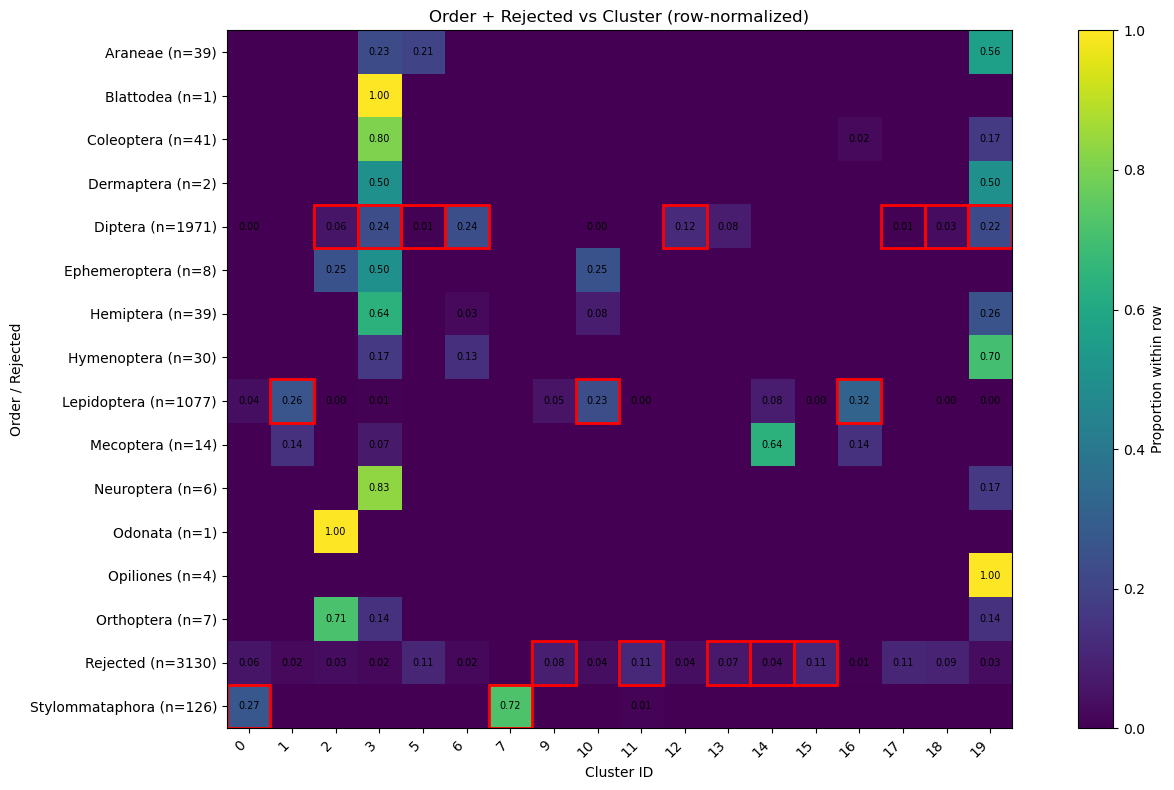

In [74]:
#   Prepare data: drop rows without cluster  
df_oc = df.dropna(subset=["cluster_id"]).copy()
df_oc["cluster_id"] = df_oc["cluster_id"].astype(int)

#   Raw confusion counts: order x cluster (only NON-rejected with order)  
df_orders = df_oc[~df_oc["is_rejected"]].dropna(subset=["order"])

conf_counts_oc = pd.crosstab(df_orders["order"], df_orders["cluster_id"])
order_counts = (
    df_orders
    .groupby("order")
    .size()
)

#   Sample size for Rejected row  
n_rejected = df_oc["is_rejected"].sum()

#   ADD REJECTED ROW (true rejection rate per cluster)  
rejected_row = (
    df_oc
    .groupby("cluster_id")["is_rejected"]
    .mean()
)

conf_counts_oc.loc["Rejected"] = rejected_row

#   Row-normalize (per row, including Rejected row)  
conf_norm_oc = conf_counts_oc.div(
    conf_counts_oc.sum(axis=1), axis=0
).fillna(0)

#   Anchor mask: True if the SINGLE anchor of that cluster belongs to that row  
anchors_oc = df_oc[df_oc["is_anchor"] == True]

# Take exactly ONE anchor per cluster
single_anchor = (
    anchors_oc
    .sort_values("cluster_id")
    .drop_duplicates(subset=["cluster_id"], keep="first")
)

# Build empty mask
anchor_mask_oc = pd.DataFrame(
    False,
    index=conf_norm_oc.index,
    columns=conf_norm_oc.columns
)

# Place exactly ONE red box per cluster
for _, row in single_anchor.iterrows():
    cid = row["cluster_id"]

    if row["is_rejected"] or pd.isna(row["order"]):
        if "Rejected" in anchor_mask_oc.index:
            anchor_mask_oc.loc["Rejected", cid] = True
    else:
        ord_val = row["order"]
        if ord_val in anchor_mask_oc.index:
            anchor_mask_oc.loc[ord_val, cid] = True

#   Align shapes  
conf_norm_oc = conf_norm_oc.sort_index().sort_index(axis=1)
anchor_mask_oc = anchor_mask_oc.reindex(
    index=conf_norm_oc.index,
    columns=conf_norm_oc.columns,
    fill_value=False
)

cm_oc = conf_norm_oc.values

#   Plot  
fig, ax = plt.subplots(figsize=(14, 8))
im = ax.imshow(cm_oc)

# Axis ticks & labels
ax.set_xticks(np.arange(len(conf_norm_oc.columns)))
ax.set_yticks(np.arange(len(conf_norm_oc.index)))

ax.set_xticklabels(conf_norm_oc.columns)
yticklabels = []
for row_name in conf_norm_oc.index:
    if row_name == "Rejected":
        yticklabels.append(f"Rejected (n={int(n_rejected)})")
    else:
        yticklabels.append(
            f"{row_name} (n={order_counts.get(row_name, 0)})"
        )

ax.set_yticklabels(yticklabels)

ax.set_xlabel("Cluster ID")
ax.set_ylabel("Order / Rejected")
ax.set_title("Order + Rejected vs Cluster (row-normalized)")

plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Highlight anchor cells with red rectangles (EXACTLY one per cluster)
for i in range(cm_oc.shape[0]):      # rows
    for j in range(cm_oc.shape[1]):  # clusters
        if anchor_mask_oc.iloc[i, j]:
            rect = Rectangle(
                (j - 0.5, i - 0.5),
                1, 1,
                fill=False,
                edgecolor="red",
                linewidth=2
            )
            ax.add_patch(rect)

# Optional: write numeric values in cells
for i in range(cm_oc.shape[0]):
    for j in range(cm_oc.shape[1]):
        val = cm_oc[i, j]
        if val > 0:
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7)

plt.colorbar(im, ax=ax, label="Proportion within row")
plt.tight_layout()
plt.show()


Order-wise normalization reveals that some taxa form compact, visually coherent groups, while others are inherently multi-modal or ambiguous, with rejected samples spread throughout the embedding space.

Which according to the HAS students, the most common reasons for rejections of insect crops are:
- Multiple insects / species per crop
- Edited pictures (as the pictures are not the original ones) had insects colored the wrong color which made it impossible to classify
- Images too hazy or transparent caused by unoriginal images as well
- Some crops do not include the full insect, this could be resolved by having better lit pictures or decreasing the threshold of mask application during detection phase whilst taking account of plausible increase in non-insect crops/noise.

Moreover, some orders are fruitful like Diptera which contains most of the non-rejected crops whilst others have one sample, this makes it difficult to train a accurate classifier even after applying weights.

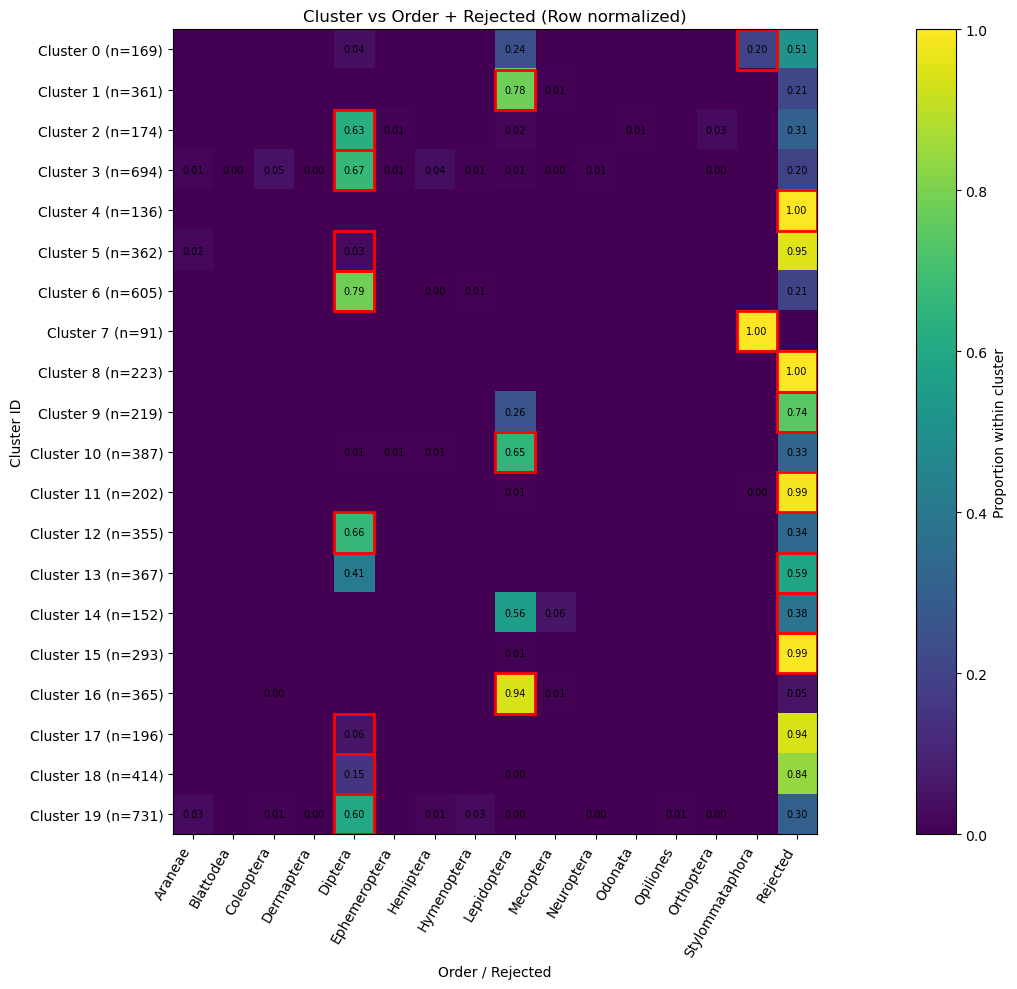

In [75]:
# Keep all rows with a cluster_id
df_co = df.dropna(subset=["cluster_id"]).copy()
df_co["cluster_id"] = df_co["cluster_id"].astype(int)

# Separate anchors
anchors_co = df_co[df_co["is_anchor"] == True]

# Counts for NON rejected samples, with a valid order
df_orders = df_co[~df_co["is_rejected"]].dropna(subset=["order"])

conf_counts_orders = pd.crosstab(
    df_orders["cluster_id"],
    df_orders["order"]
)

# Counts for rejected samples (no order by definition)
rejected_counts = (
    df_co.groupby("cluster_id")["is_rejected"]
    .sum()
    .rename("Rejected")
)

# Combine into one table: cluster x (orders + Rejected)
conf_counts_full = conf_counts_orders.join(
    rejected_counts,
    how="outer"
).fillna(0)

# Ensure numeric
conf_counts_full = conf_counts_full.astype(float)

# Row normalize over ALL columns (orders + Rejected)
conf_norm_co = conf_counts_full.div(
    conf_counts_full.sum(axis=1),
    axis=0
).fillna(0)

cm_co = conf_norm_co.values

# Take EXACTLY one anchor per cluster (first one found)
single_anchor = (
    anchors_co
    .sort_values("cluster_id")
    .drop_duplicates(subset=["cluster_id"], keep="first")
)

# Build empty mask with same shape as conf_norm_co
anchor_mask_co = pd.DataFrame(
    False,
    index=conf_norm_co.index,
    columns=conf_norm_co.columns
)

# Place exactly ONE red box per cluster
for _, row in single_anchor.iterrows():
    cid = row["cluster_id"]

    if row["is_rejected"] or pd.isna(row["order"]):
        # Anchor is rejected → mark Rejected column
        if "Rejected" in anchor_mask_co.columns:
            anchor_mask_co.loc[cid, "Rejected"] = True
    else:
        # Anchor has an order → mark that order column
        ord_val = row["order"]
        if ord_val in anchor_mask_co.columns:
            anchor_mask_co.loc[cid, ord_val] = True

cluster_counts = df.groupby("cluster_id").size().sort_index()

y_labels = [
    f"Cluster {cid} (n={cluster_counts.get(cid, 0)})"
    for cid in conf_norm_co.index
]

x_labels = list(conf_norm_co.columns)

fig, ax = plt.subplots(figsize=(20, 10))
im = ax.imshow(cm_co)

ax.set_xticks(np.arange(len(x_labels)))
ax.set_yticks(np.arange(len(y_labels)))

ax.set_xticklabels(x_labels)
ax.set_yticklabels(y_labels)

ax.set_xlabel("Order / Rejected")
ax.set_ylabel("Cluster ID")
ax.set_title("Cluster vs Order + Rejected (Row normalized)")

plt.setp(ax.get_xticklabels(), rotation=60, ha="right")

for i in range(cm_co.shape[0]):      # clusters (rows)
    for j in range(cm_co.shape[1]):  # orders + rejected (cols)
        if anchor_mask_co.iloc[i, j]:
            rect = Rectangle(
                (j - 0.5, i - 0.5),
                1, 1,
                fill=False,
                edgecolor="red",
                linewidth=2
            )
            ax.add_patch(rect)

for i in range(cm_co.shape[0]):
    for j in range(cm_co.shape[1]):
        val = cm_co[i, j]
        if val > 0:
            ax.text(
                j, i, f"{val:.2f}",
                ha="center", va="center", fontsize=7
            )

plt.colorbar(im, ax=ax, label="Proportion within cluster")
plt.tight_layout()
plt.show()


#### Mixed clusters reflect ambiguity rather than error
Some clusters show moderate dominance but still contain non-trivial proportions of other orders or rejected samples:
- Cluster 0:
    - 51% Rejected, 20% Stylommatophora
- Cluster 13:
    - 59% Rejected, 41% Diptera
- Cluster 14:
    - 56% Lepidoptera, 38% Rejected

- Interpretation:
    - These clusters sit near decision boundaries in representation space. They are not purely erroneous, but reflect visual overlap across taxa, reinforcing the need for soft rather than hard decisions.

#### Across clusters:
- Some are taxonomically clean
- Some are almost entirely rejected
- Others sit in between

#### Implications of rejection dominance and clustering quality
As the rejection pool dominates a significant portion of the clusters, it is hypothesized that overall performance could be improved by better mitigating rejected samples, either through refined feature representations or adaptive cluster handling.

Crucially, identifying the optimal number of clusters plays a central role. Suboptimal clustering granularity leads to:
- fragmented or overly mixed clusters
- inflated rejection rates
- reduced interpretability

However, it is important to note that this limitation is not unique to the clustering-based approach. A conventional pre-trained, transfer-learned CNN classifier would face similar or greater challenges, as it typically operates under a closed-set assumption. In contrast, the current approach naturally supports open-set and open–closed-set scenarios, where ambiguous or out-of-distribution samples can be explicitly rejected rather than misclassified.

In [76]:
# If is_rejected is "yes"/"no", normalize to bool
if df["is_rejected"].dtype == object:
    df["is_rejected"] = df["is_rejected"].str.lower().eq("yes")

# label that includes rejected
df["label_with_rejected"] = np.where(
    df["is_rejected"],
    "rejected",
    df["order"].fillna("unknown")
)

In [77]:
SIM_FEATURE = "similarity_to_anchor"

In [78]:
def plot_cluster_label_splits_grid(df, cluster_ids, feature, x_min=None, x_max=None):
    n = len(cluster_ids)
    cols = 3
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4), sharex=False)
    axes = axes.flatten()

    for ax, cid in zip(axes, cluster_ids):
        sub = df[df["cluster_id"] == cid].copy()

        if sub.empty:
            ax.set_title(f"Cluster {cid}\n(no data)")
            ax.axis("off")
            continue

        anchors = sub[sub["is_anchor"]]
        if anchors.empty:
            ax.set_title(f"Cluster {cid}\n(no anchor)")
            ax.axis("off")
            continue

        anchor_label = anchors["label_with_rejected"].mode()[0]

        same = sub[sub["label_with_rejected"] == anchor_label]
        diff = sub[sub["label_with_rejected"] != anchor_label]

        same = same.dropna(subset=[feature])
        diff = diff.dropna(subset=[feature])

        if not same.empty:
            same[feature].plot(kind="kde", ax=ax, label="Same label")
        if not diff.empty:
            diff[feature].plot(kind="kde", ax=ax, label="Different label")

        ax.set_title(f"Cluster {cid}\nAnchor = {anchor_label}")
        ax.set_xlabel(feature)
        ax.set_ylabel("Density")

        if x_min is not None or x_max is not None:
            ax.set_xlim(left=x_min, right=x_max)

        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)

    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


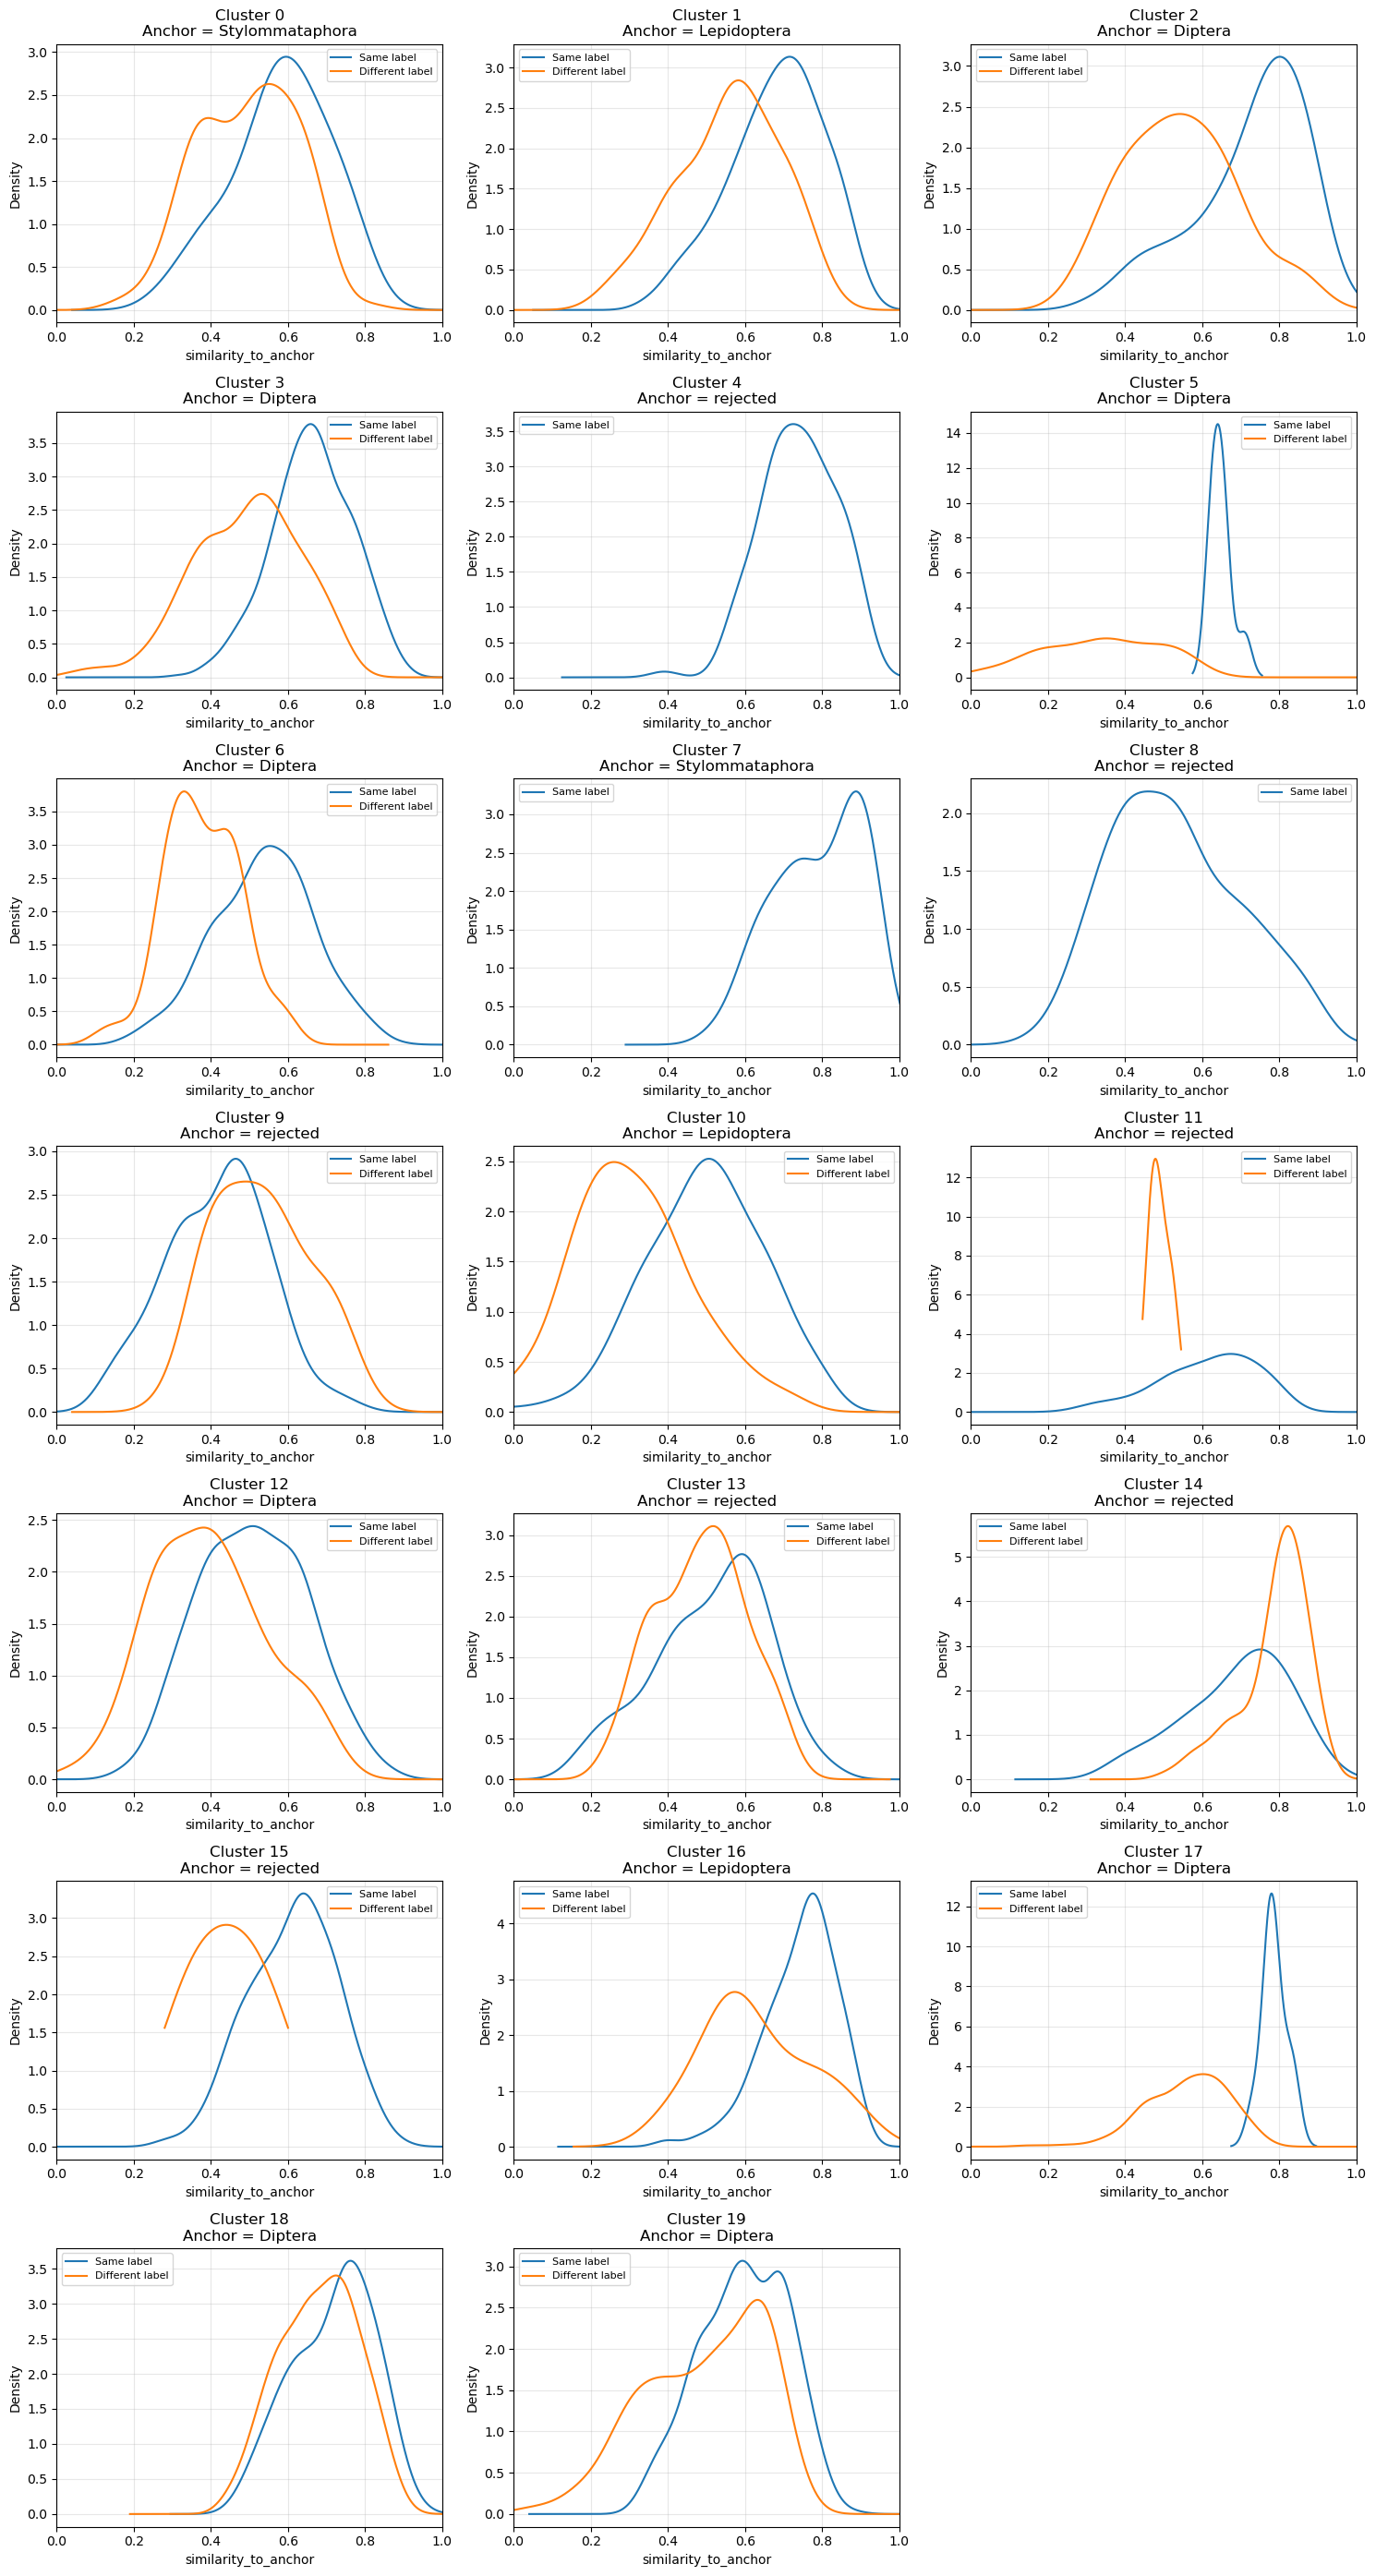

In [79]:
example_clusters = sorted(df["cluster_id"].unique())[:20]
plot_cluster_label_splits_grid(df, example_clusters, feature=SIM_FEATURE, x_min= 0.0, x_max=1.0)

Cluster-wise analysis shows that similarity to the anchor consistently correlates with label consistency, but substantial overlap and cluster-specific behavior prevent the use of a universal similarity threshold, supporting its role as a soft, supportive signal rather than a decisive rule.

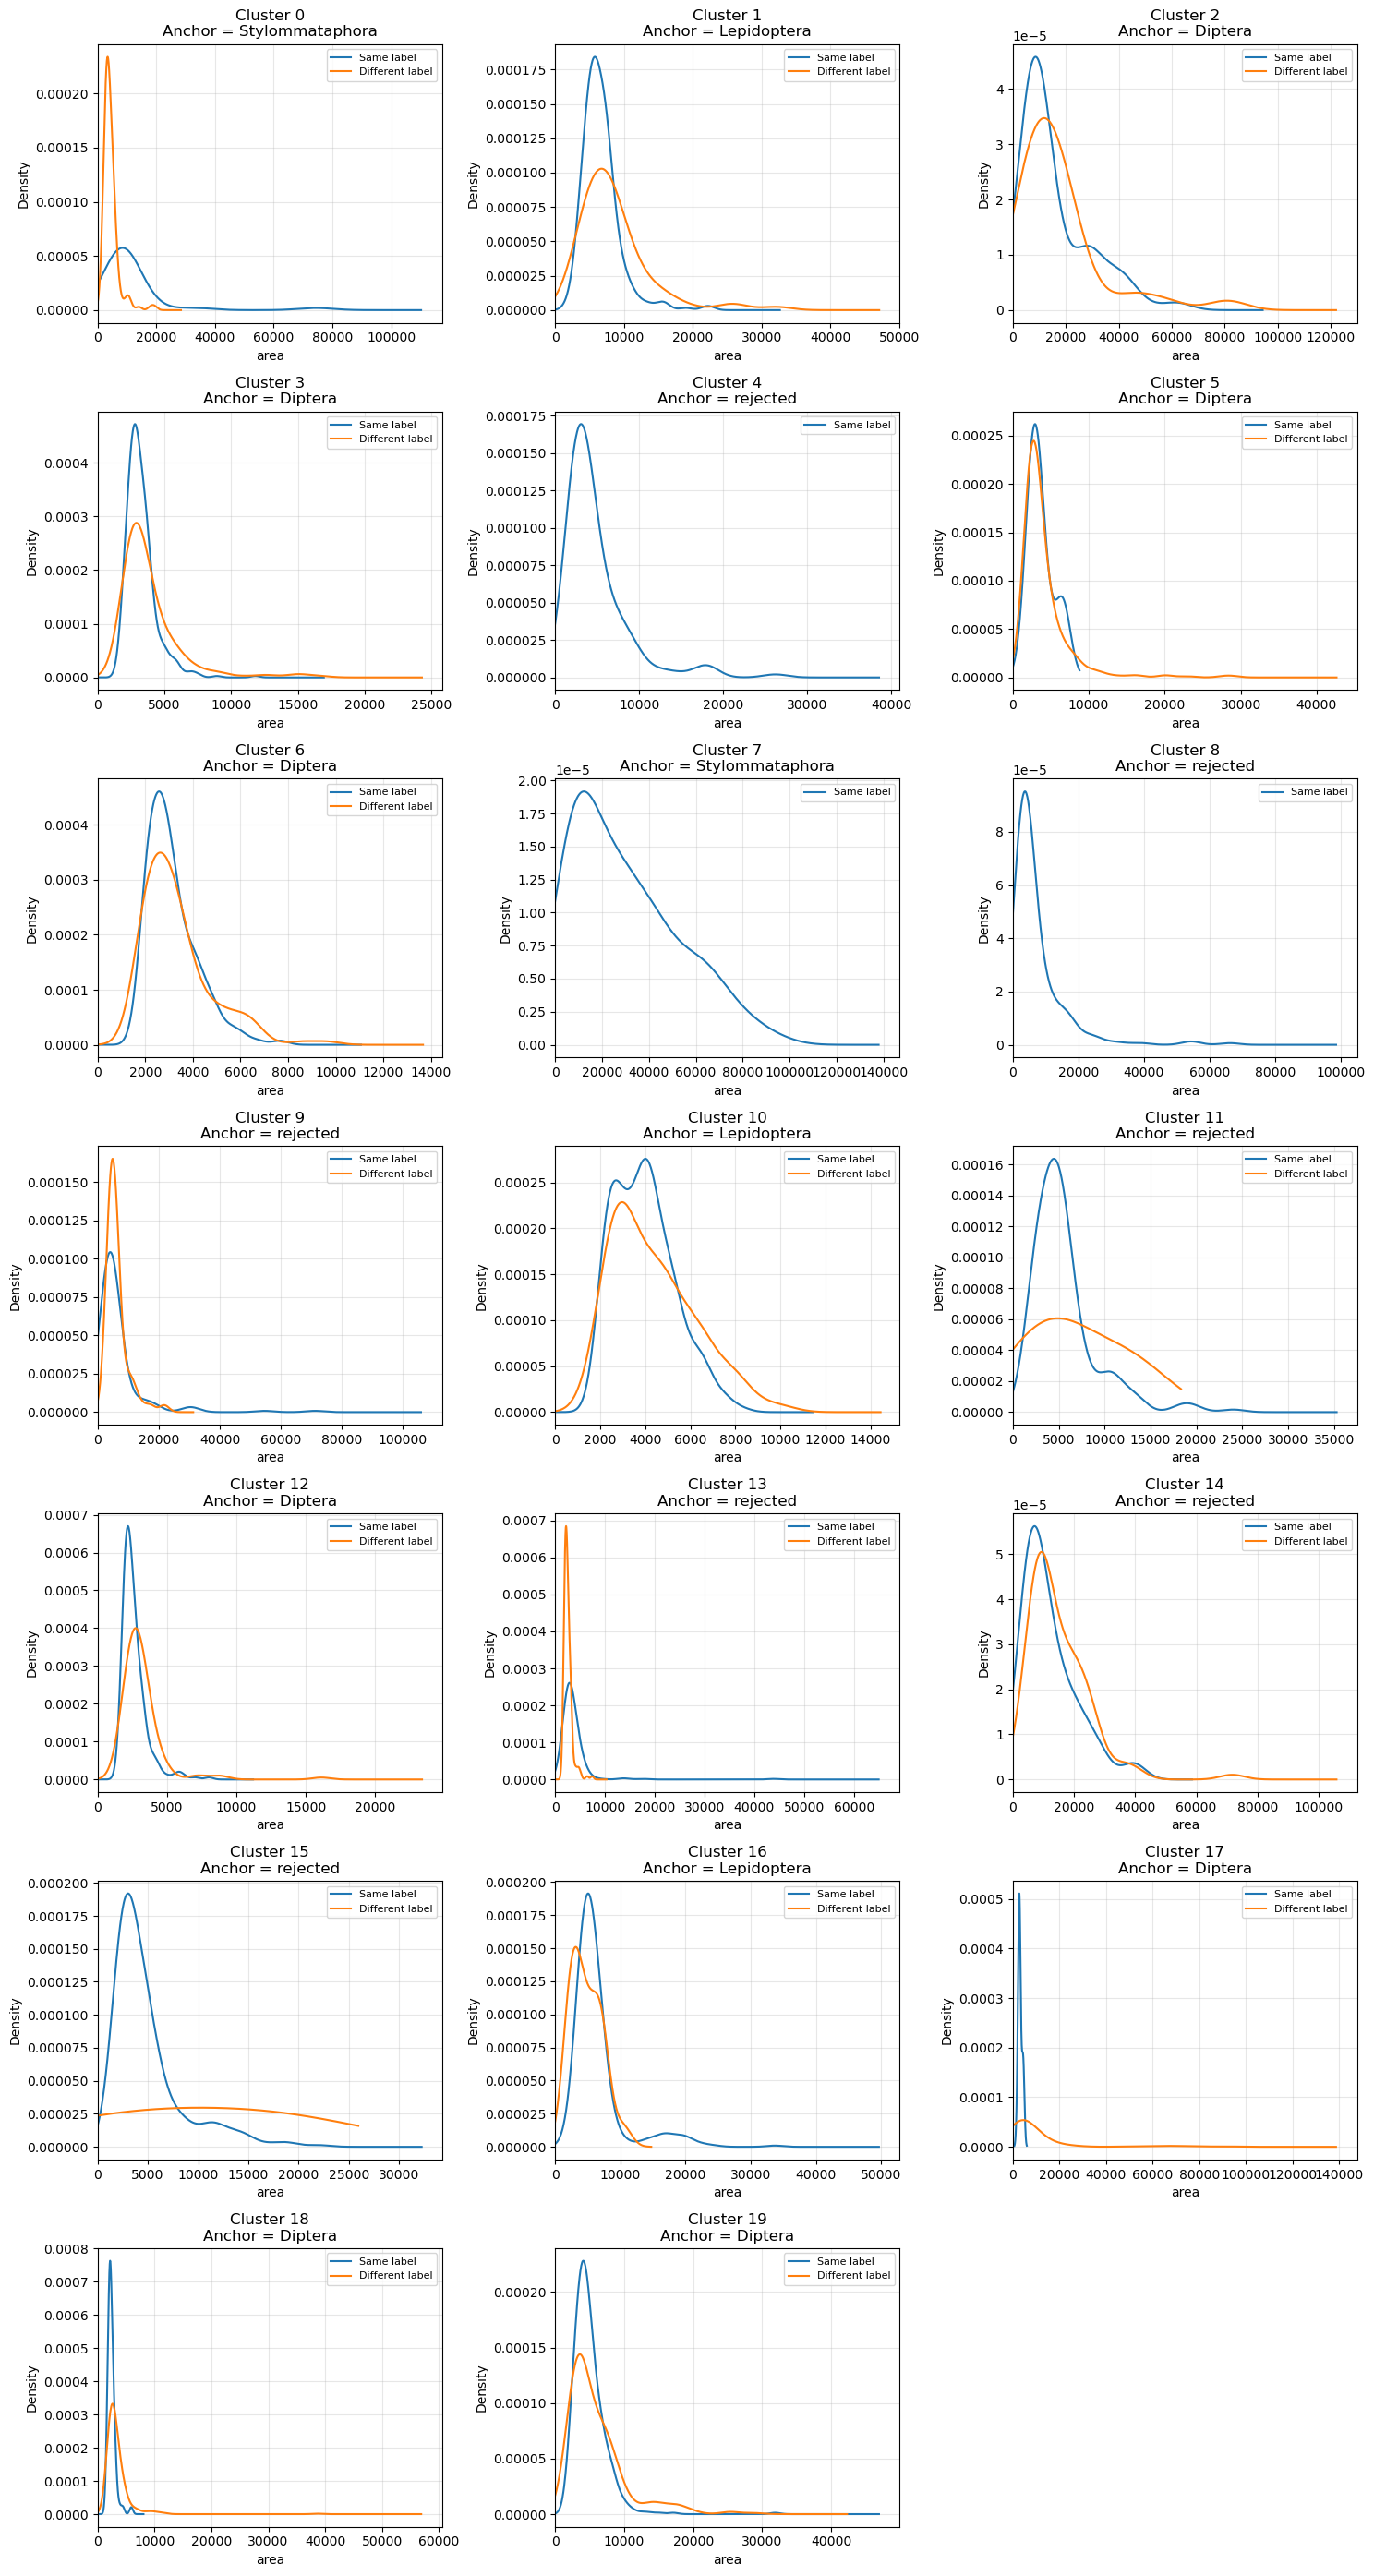

In [80]:
example_clusters = sorted(df["cluster_id"].unique())[:20]
plot_cluster_label_splits_grid(df, example_clusters, feature='area', x_min= 0)

Cluster-wise analysis shows that object area exhibits strong skew and substantial overlap between same-label and different-label samples across clusters, indicating that area is a contextual feature rather than a reliable signal for rejection or label consistency. It also indicated that the original threshold made during detection and cropping phase might've rules out a lot of "too small to identify" rejections.

In [81]:
FEATURES = ["area", "std", "bright_fraction", "dark_fraction", "min_val", "max_val"]

print("Whole dataset describe:")
print(df[FEATURES].describe().T)

Whole dataset describe:
                  count         mean          std          min          25%  \
area             6496.0  5606.721598  7063.227140  1504.000000  2653.875000   
std              6496.0    30.511106    10.229245    15.001027    22.669203   
bright_fraction  6496.0     0.016316     0.077165     0.000000     0.000000   
dark_fraction    6496.0     0.055684     0.066055     0.000000     0.010655   
min_val          6496.0    19.566964    17.864165     0.000000     5.000000   
max_val          6496.0   165.480757    35.374102    89.000000   137.000000   

                         50%          75%           max  
area             3701.500000  5718.875000  92966.000000  
std                28.616369    36.786470     79.638926  
bright_fraction     0.000000     0.000000      0.814455  
dark_fraction       0.035629     0.074781      0.583231  
min_val            16.000000    30.000000    165.000000  
max_val           158.000000   188.000000    255.000000  


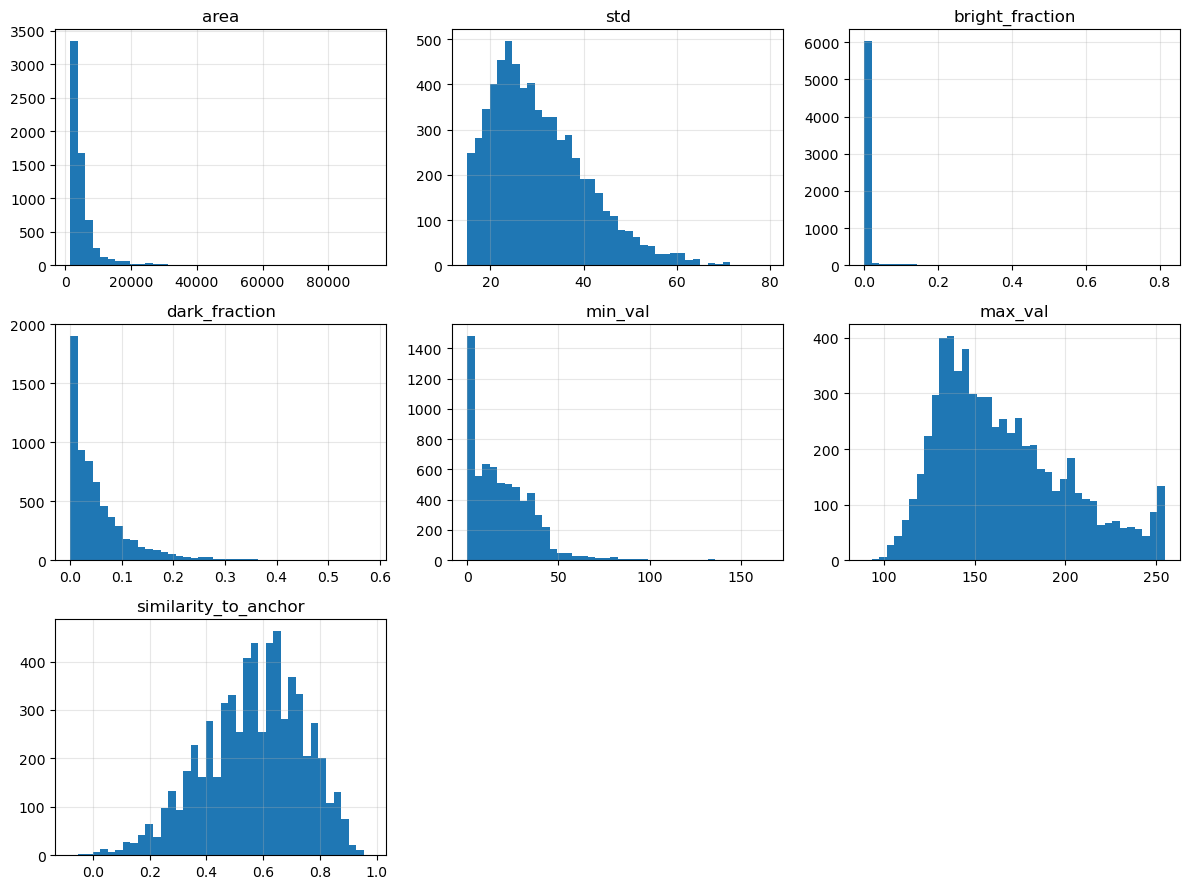

In [82]:
FEATURES = ["area", "std", "bright_fraction", "dark_fraction", "min_val", "max_val", 'similarity_to_anchor']

cols = 3
rows = math.ceil(len(FEATURES) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3))
axes = axes.flatten()

for ax, col in zip(axes, FEATURES):
    df[col].hist(bins=40, ax=ax)
    ax.set_title(col)
    ax.grid(alpha=0.3)

# Turn off unused
for ax in axes[len(FEATURES):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

This figure shows the marginal distributions of the extracted features across all samples, independent of rejection status. The goal here is to understand scale, skewness, and statistical behavior of each feature.

Overall feature distributions reveal strong skewness and outlier sensitivity for most low-level image features, while similarity_to_anchor exhibits a well-behaved, bounded distribution.

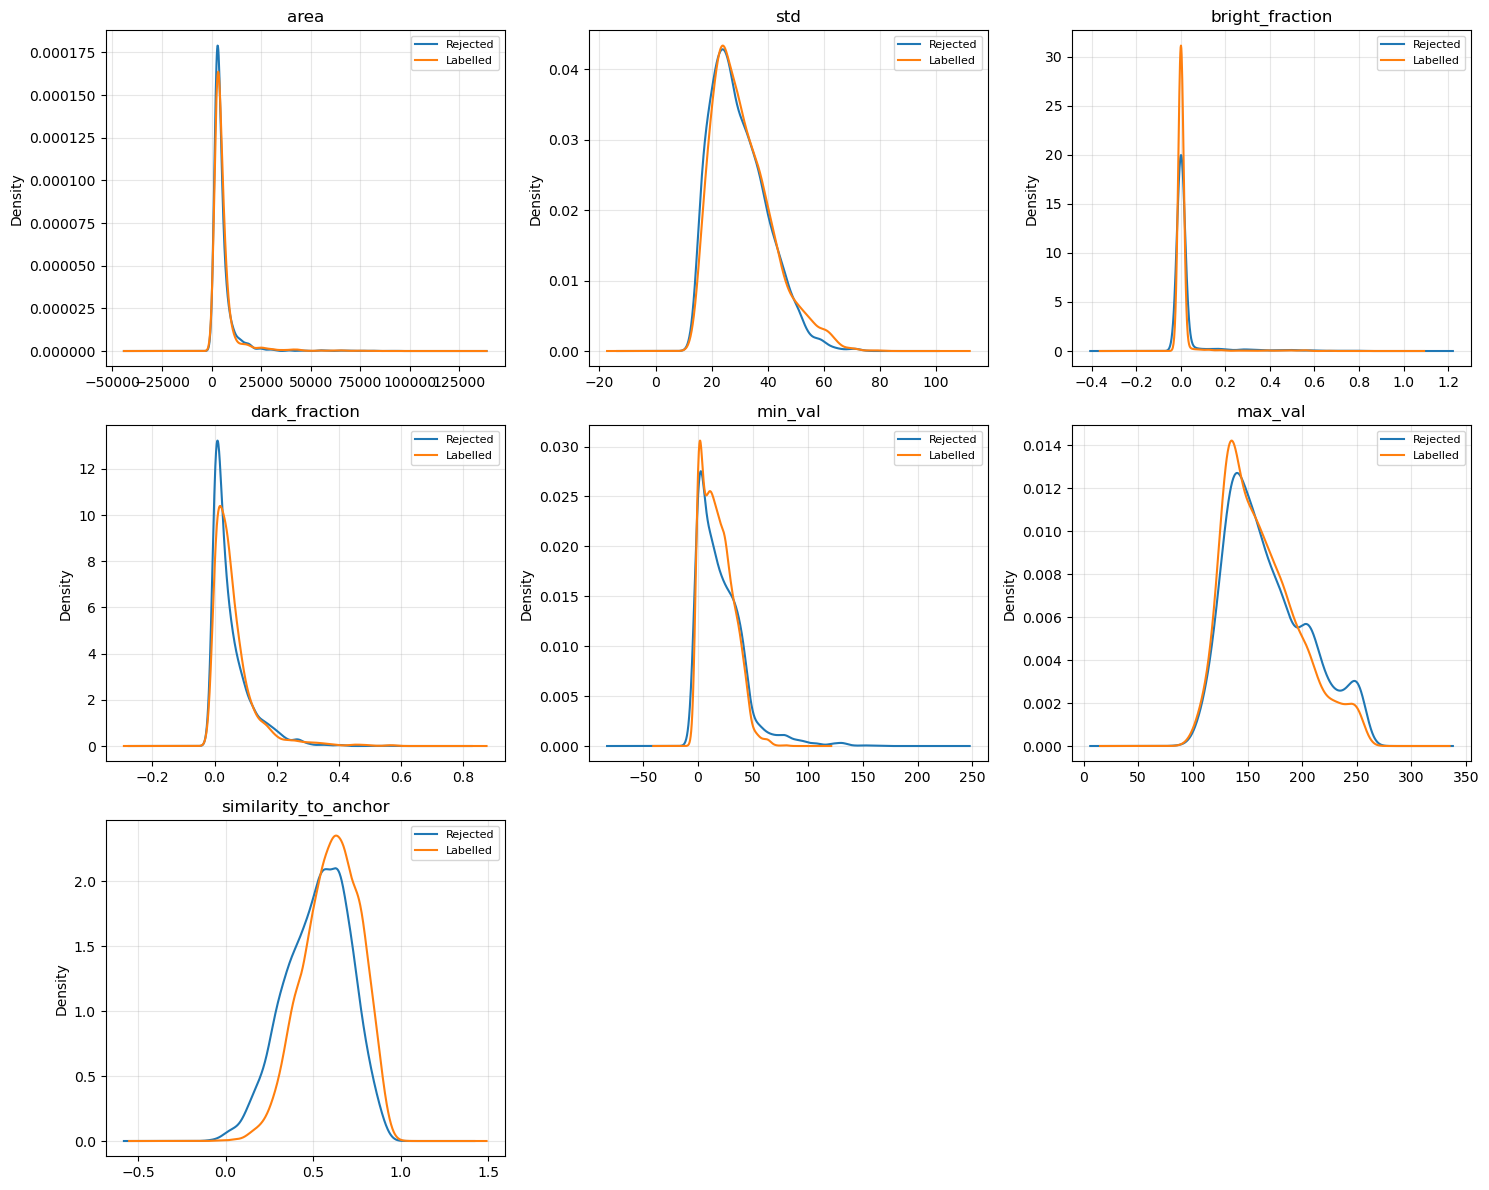

In [83]:
cols = 3
rows = math.ceil(len(FEATURES) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
axes = axes.flatten()

for ax, feat in zip(axes, FEATURES):
    df[df["is_rejected"]][feat].plot(kind="kde", ax=ax, label="Rejected")
    df[~df["is_rejected"]][feat].plot(kind="kde", ax=ax, label="Labelled")

    ax.set_title(feat)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

for ax in axes[len(FEATURES):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

Distribution analysis shows strong overlap between rejected and labelled samples across most low-level features, with similarity_to_anchor providing the clearest—but still limited—class separation, reinforcing the need for multivariate decision logic.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def find_best_threshold(
    df,
    feature,
    n_steps=300,
    direction="high_is_rejected",
    target_accuracies=None,
    plot=True
):
    data = df[[feature, "is_rejected"]].dropna()
    if data.empty:
        print(f"No data for feature {feature}")
        return None

    x = data[feature].values
    y = data["is_rejected"].astype(int).values  # 1=rejected, 0=not rejected

    lo, hi = x.min(), x.max()
    thresholds = np.linspace(lo, hi, n_steps)

    acc_curve = []
    thr_curve = []

    best_thr = None
    best_acc =  np.inf

    for thr in thresholds:
        if direction == "high_is_rejected":
            pred = (x >= thr).astype(int)
        else:
            pred = (x <= thr).astype(int)

        acc = (pred == y).mean()

        acc_curve.append(acc)
        thr_curve.append(thr)

        if acc > best_acc:
            best_acc = acc
            best_thr = thr

    print(f"\nFeature: {feature}")
    print(f"Best threshold: {best_thr:.6f}")
    print(f"Best accuracy : {best_acc:.4f}")
    target_results = {}

    if target_accuracies is not None:
        max_acc = max(acc_curve)

        for target in target_accuracies:
            target = target / 100 if target > 1 else target

            if target > max_acc:
                print(
                    f"⚠️ Target accuracy {target:.2f} not achievable "
                    f"(max = {max_acc:.4f}) → using best threshold"
                )
                target_results[target] = (best_thr, best_acc)
            else:
                idx = np.argmin(np.abs(np.array(acc_curve) - target))
                target_results[target] = (thr_curve[idx], acc_curve[idx])

                print(
                    f"🎯 Target accuracy {target:.2f} → "
                    f"threshold = {thr_curve[idx]:.6f}, "
                    f"actual acc = {acc_curve[idx]:.4f}"
                )
    if plot:
        plt.figure(figsize=(9, 5))
        plt.plot(
            thr_curve,
            acc_curve,
            label=f"Accuracy curve | Best = {best_acc:.3f}",
            linewidth=2
        )

        plt.axvline(
            best_thr,
            linestyle="  ",
            linewidth=2,
            label=f"Best threshold = {best_thr:.4f}"
        )

        plt.xlabel(feature)
        plt.ylabel("Accuracy")
        plt.title(f"Threshold scan for {feature}")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

    return {
        "best_threshold": best_thr,
        "best_accuracy": best_acc,
        "accuracy_curve": acc_curve,
        "thresholds": thr_curve,
        "targets": target_results
    }



Feature: similarity_to_anchor
✅ Best threshold: 0.462408
✅ Best accuracy : 0.5893
🎯 Target accuracy 0.50 → threshold = 0.841739, actual acc = 0.5005


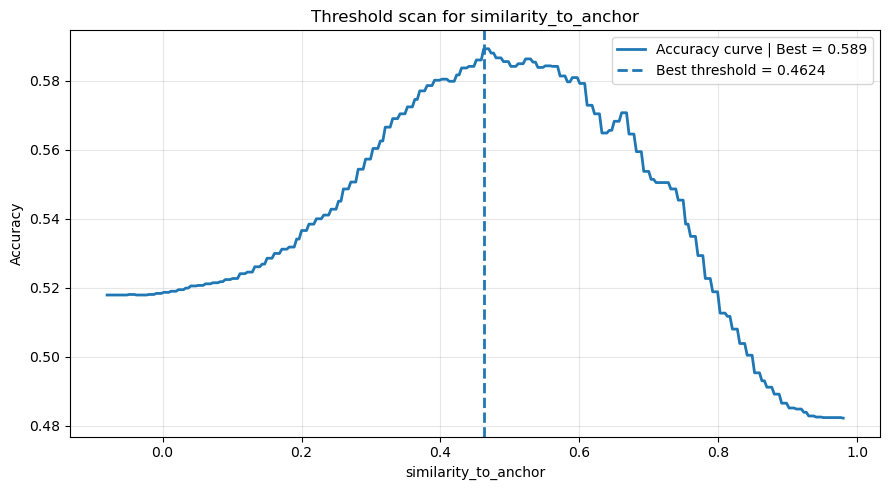

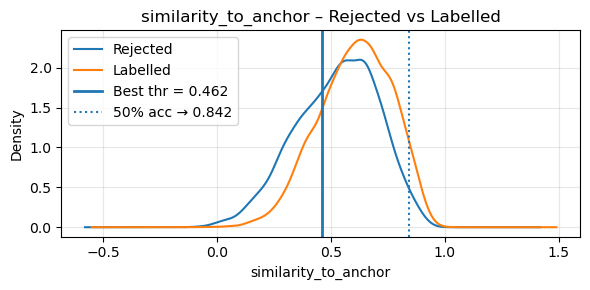

In [ ]:
feat = "similarity_to_anchor"

result = find_best_threshold(
    df,
    feature=feat,
    direction="low_is_rejected",  
    target_accuracies=[50]
)

best_thr = result["best_threshold"]
target_thrs = result["targets"]

plt.figure(figsize=(6, 3))


df[df["is_rejected"] == True][feat].dropna().plot(
    kind="kde", label="Rejected"
)

df[df["is_rejected"] == False][feat].dropna().plot(
    kind="kde", label="Labelled"
)

plt.axvline(
    best_thr,
    linestyle="-",
    linewidth=2,
    label=f"Best thr = {best_thr:.3f}"
)

for acc, (thr, actual_acc) in target_thrs.items():
    plt.axvline(
        thr,
        linestyle=":",
        linewidth=1.5,
        label=f"{int(acc*100)}% acc → {thr:.3f}"
    )

plt.title(f"{feat} – Rejected vs Labelled")
plt.xlabel(feat)
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Accuracy curve shape indicates overlap, not noise
Threshold scanning shows that similarity_to_anchor provides a weak but consistent signal for rejection (best accuracy ≈ 0.59), with substantial class overlap preventing any high-confidence cutoff. Currently this validates its use as a supportive feature rather than a standalone decision rule however it could change after getting more and more labeled data and finding better number of clusters estimates.

The smooth rise and fall of the accuracy curve (rather than sharp spikes) suggests:
- The feature is systematically related to rejection
- But the relationship is not strong enough to create a clean cutoff
The decline in accuracy at high similarity values (> ~0.6) indicates that:
- High similarity to an anchor is not uniquely associated with rejection
- At extreme thresholds, misclassification increases rapidly

This confirms that hard filtering at high similarity would be harmful. A run with optimal number of clusters will make it clearer if a cutoff at a specific similarity score would benefit the model to classify correctly. As we gather more and more labelled data this could be used as a pipeline to keep increasing the models performance.

However, the final conclusion is that with higher resolution crops this methodology might be beneficial which would open up the very closed-set problem of insect detection and classification.
